# Multi-Task vs. Independent DistilBERT for Automated CVSS v3.1 Base Metric Prediction

The Common Vulnerability Scoring System (CVSS) provides a standardized method for assessing the severity of software vulnerabilities. However, manually assigning CVSS base metrics to large numbers of vulnerabilities is time-consuming, as new vulnerabilities appear daily ([NVD,2026](https://nvd.nist.gov/general/nvd-dashboard)). Automated CVSS vector and base metrics prediction could therefore support faster and more scalable vulnerability severity assessment.

This study focuses on automatically predicting the eight CVSS v3.1 Base Metrics such as Attack Vector (AV), Attack Complexity (AC), Privileges Required (PR), User Interaction (UI), Scope (S), Confidentiality (C), Integrity (I), and Availability (A) from textual Common Vulnerabilities and Exposures (CVE) descriptions using DistilBERT.

Because the eight Base Metrics describe different but potentially related characteristics of the same vulnerability, there are two approaches. The first approach uses a multi-task DistilBERT model with a shared text encoder and separate prediction heads for the eight metrics, allowing the model to learn shared representations across tasks. The second approach uses independent DistilBERT models, with a separate model trained for each CVSS Base Metric.

The study compares these two approaches using the same dataset, preprocessing procedure, training configuration, and data splits. The goal is to determine whether multi-task learning provides an advantage over learning each metric independently.

Based on this experimental setup, the study addresses the following research questions:

## Research Questions

1. RQ1: Does multi-task DistilBERT improve the prediction performance of the eight CVSS v3.1 Base Metrics compared with independently trained DistilBERT models?
2. RQ2: Does the choice between multi-task and independent prediction affect the accuracy of the resulting CVSS severity-level classification (Low, Medium, High, and Critical)?
3. RQ3: How accurately can the complete CVSS v3.1 Base Vector be reconstructed from the predicted Base Metrics under multi-task and independent prediction?

## 1. Imports & Configuration

This section imports the libraries required for data processing, visualization, transformer models, and model evaluation. These include Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, transformers and pytorch.

In [1]:
import pandas as pd
from datasets import Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import transformers
from transformers import Trainer, DataCollatorForSeq2Seq, AutoModelForSequenceClassification, AutoModel, AutoTokenizer, TrainingArguments, Trainer, DataCollatorWithPadding, AutoModelForCausalLM
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, precision_recall_fscore_support
from torch.utils.data import DataLoader

## 2. Load Datasets

This section loads the CVE dataset from the National Vulnerability Database (NVD), covering vulnerabilities published from 1999 to 2026. The dataset was obtained from the NVD CSV repository through open source github. ([NVD-csv github, 2026](https://github.com/flying-coyote/nvd-csv/tree/main/data/shards))


In [2]:
df = pd.read_csv("cvss_data.csv")
df.head()

,cve_id,description_en,cvss_version,cvss_base_score,cvss_vector
0,CVE-2023-0001,An information exposure vulnerability in the P...,3.1,6.0,CVSS:3.1/AV:L/AC:L/PR:H/UI:N/S:U/C:H/I:N/A:H
1,CVE-2023-0002,A problem with a protection mechanism in the P...,3.1,5.5,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:N/I:N/A:H
2,CVE-2023-0003,A file disclosure vulnerability in the Palo Al...,3.1,6.5,CVSS:3.1/AV:N/AC:L/PR:L/UI:N/S:U/C:H/I:N/A:N
3,CVE-2023-0004,A local file deletion vulnerability in Palo Al...,3.1,6.5,CVSS:3.1/AV:N/AC:L/PR:H/UI:N/S:U/C:N/I:H/A:H
4,CVE-2023-0005,A vulnerability in Palo Alto Networks PAN-OS s...,3.1,4.1,CVSS:3.1/AV:L/AC:H/PR:H/UI:N/S:U/C:H/I:N/A:N


## 3. Dataset Exploration

This section explores the distribution of CVSS versions, CVSS base scores, severity levels, and each CVSS Base Metrics distribution in the dataset. To ensure a consistent and fair comparison between the two prediction approaches, one CVSS version is selected for the experiments. As shown in Graph 1, CVSS v3.1 contains the largest number of CVE records; therefore, CVSS v3.1 is selected as the base dataset for the experiments.

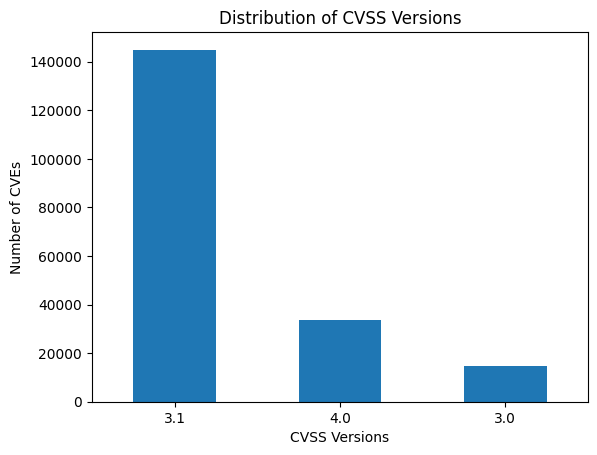

In [3]:
df["cvss_version"].value_counts().plot(kind="bar")

plt.title("Distribution of CVSS Versions")
plt.xlabel("CVSS Versions")
plt.ylabel("Number of CVEs")
plt.xticks(rotation=0)

plt.show()

Additionally, in the CVSS v3.1 dataset, it is found that it has base scores mostly between 4.0 and 10.0. This indicates that Medium and High severity vulnerabilities are more common in the dataset.

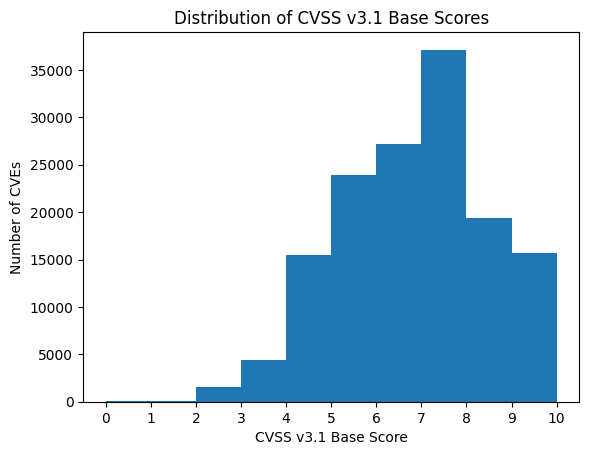

In [4]:
df_31 = df[df["cvss_version"] == 3.1].copy()
plt.hist(df_31["cvss_base_score"])

plt.xlabel("CVSS v3.1 Base Score")
plt.ylabel("Number of CVEs")
plt.title("Distribution of CVSS v3.1 Base Scores")

plt.xticks(np.arange(0, 11, 1))
plt.show()

To identify the severity of the vulnerabilities, the following tables from the Forum of Incident Response and Security Teams ([FIRST, June-2019](https://www.first.org/cvss/v3-1/cvss-v31-specification_r1.pdf)) will be used to apply on the datasets. It is found that the Medium severity contains the most records (66,615), followed by High (56,567), Critical (15,704), and Low (6,043).

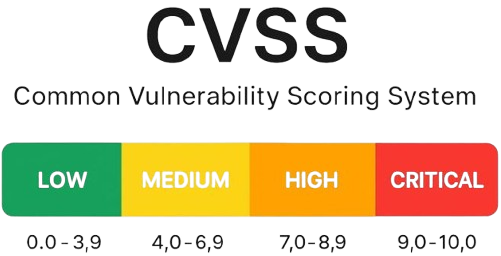

In [5]:
def get_severity(score):
    if score < 4.0:
        return "Low"
    elif score < 7.0:
        return "Medium"
    elif score < 9.0:
        return "High"
    else:
        return "Critical"

df_31["severity"] = df_31["cvss_base_score"].apply(get_severity)
severity_counts = df_31["severity"].value_counts()

severity_counts

,count
severity,
Medium,66615
High,56567
Critical,15704
Low,6043


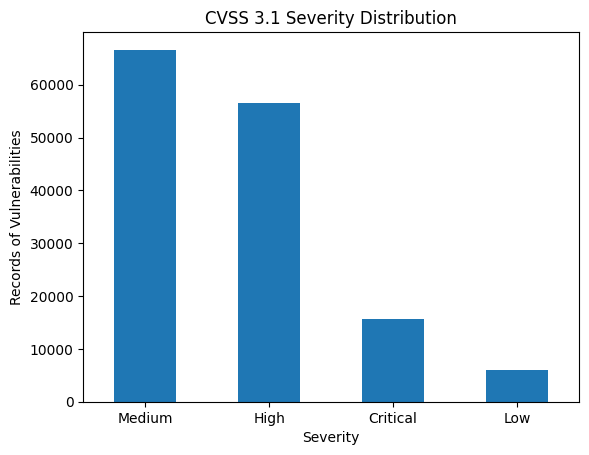

In [6]:
severity_counts.plot(kind="bar")

plt.title("CVSS 3.1 Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Records of Vulnerabilities")
plt.xticks(rotation=0)
plt.show()

Furthermore, based on the visualization below, it is found that the distribution of the eight CVSS v3.1 base metrics are not evenly distributed, with some values occurring more frequently than others. For example, AV:N, AC:L, UI:N, and S:U are particularly dominant, while some values such as AV:P and PR:H occur less frequently.

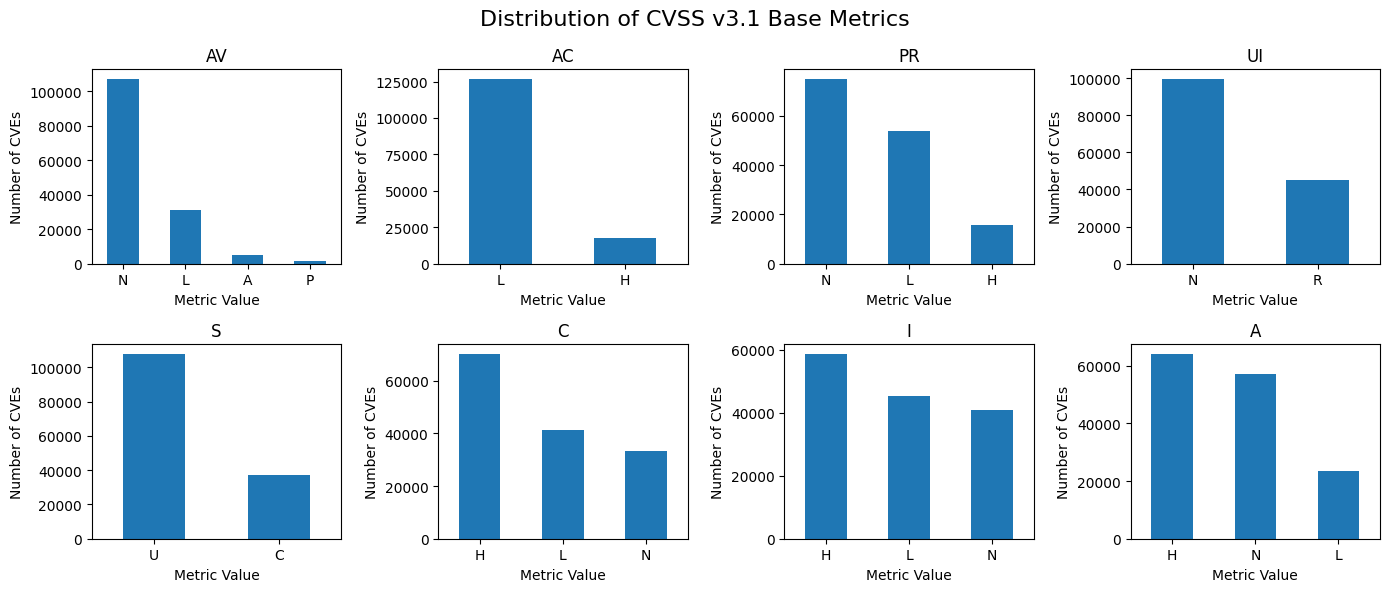

In [7]:
# Extract CVSS v3.1 Base Metrics from the vector
metrics = ["AV", "AC", "PR", "UI", "S", "C", "I", "A"]
for metric in metrics:
    df_31[metric] = df_31["cvss_vector"].str.extract(rf'/{metric}:([^/]+)')

# Visualize all metrics for CVSS v3.1
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, metric in zip(axes.flat, metrics):
    df_31[metric].value_counts().plot(kind="bar",ax=ax)

    ax.set_title(metric)
    ax.set_xlabel("Metric Value")
    ax.set_ylabel("Number of CVEs")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Distribution of CVSS v3.1 Base Metrics", fontsize=16)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

This section preprocesses the dataset to ensure that the CVE descriptions are clean and consistent for model training. The dataset is filtered to CVSS v3.1 vulnerabilities, and CVE descriptions are cleaned to remove irrelevant or potentially leakage information, such as CVE IDs or IP addresses. Due to computational constraints, we randomly sample 20,000 vulnerabilities using a fixed random seed, then parse the corresponding CVSS vectors into the eight individual metrics (AV, AC, PR, UI, S, C, I, and A). The resulting dataset is divided into training, validation, and test sets using an 80/10/10 split, and these sets will be used consistently for both approaches, such as the Multi-Task and Independent DistilBERT models for CVSS v3.1 prediction, to ensure a fair comparison.

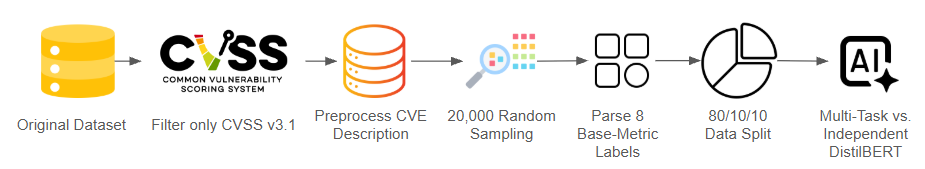

### 4.1 CVE Description Cleaning

Because transformer models such as DistilBERT depend on the relationships between each word and their surrounding context, we avoid excessive preprocessing and focus only on removing unnecessary URLs, masking IP addresses, CVE IDs, and CVSS vectors to prevent information leakage, and removing extra whitespace from the vulnerability descriptions.

In [8]:
import re

def clean_cve_description(text):

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Mask IP addresses
    text = re.sub(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b', '<ip_address>', text)

    # Mask CVE IDs
    text = re.sub(r'cve-\d{4}-\d{4,}', '<cve_ref>', text)

    # Mask CVSS vectors
    text = re.sub(r'CVSS\s*:\s*3\.[01]\s*(?:/\s*[A-Z]{1,3}\s*:\s*[A-Z]+)+','<cvss_vector>', text, flags=re.IGNORECASE)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_31["cleaned_description"] = df_31["description_en"].apply(clean_cve_description)
df_31[["cleaned_description"]].head()

,cleaned_description
0,An information exposure vulnerability in the P...
1,A problem with a protection mechanism in the P...
2,A file disclosure vulnerability in the Palo Al...
3,A local file deletion vulnerability in Palo Al...
4,A vulnerability in Palo Alto Networks PAN-OS s...


### 4.2 Description Length Analysis and Dataset Filtering

This section analyzes the length of the cleaned CVE descriptions to determine an appropriate word-count range for the experiments. A boxplot is used to identify unusually short and long descriptions. Several word-count thresholds are compared to balance data retention and the removal of extreme outliers. Descriptions containing fewer than 20 words are excluded due to their limited textual information, while an upper limit of 125 words is selected to remove unusually long descriptions. Based on this analysis, descriptions containing 20–125 words are retained. After applying the word-count filter, 20,000 records are randomly sampled from the resulting dataset using a fixed random seed.

In [9]:
# Word Count Summary
df_31["word_count"] = df_31["cleaned_description"].str.split().str.len()
df_31["word_count"].describe()

,word_count
count,144929.000000
mean,53.587315
std,48.353677
min,2.000000
25%,26.000000
50%,40.000000
75%,67.000000
max,686.000000


The boxplot shows that CVE description lengths are concentrated within a relatively narrow range, while numerous extreme long-description outliers are present. This supports applying a word-count range to reduce extreme cases while retaining the majority of the data.

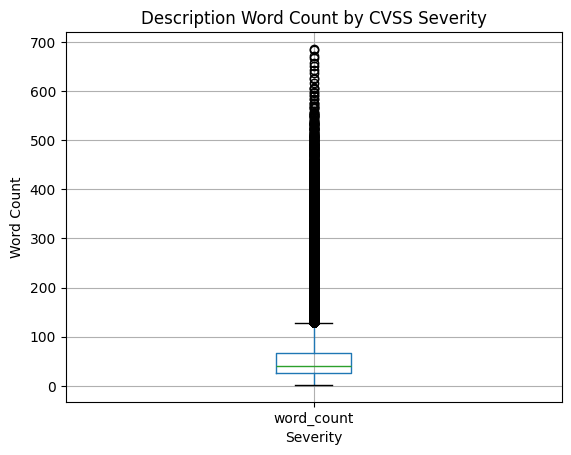

In [10]:
# Boxplot based on severity
df_31.boxplot(column="word_count")

plt.title("Description Word Count by CVSS Severity")
plt.suptitle("")
plt.xlabel("Severity")
plt.ylabel("Word Count")
plt.show()

Examples of extremely short and long descriptions are inspected to better understand the identified outliers.

In [11]:
# Short Outlier Example
short = df_31[df_31["word_count"] < 3]
print("Short Outlier Examples:")
print(short["cleaned_description"].head(10).tolist())

# Longest Outlier Example
long = df_31.loc[df_31["word_count"].idxmax()]
print("\nLongest Outlier Example:")
print(f"{long['cleaned_description'][:200]}...")

Short Outlier Examples:
['Information disclosure', 'Information disclosure', 'Multiple CWE-78', 'Vulnerability Title', '## Summary']

Longest Outlier Example:
In the Linux kernel, the following vulnerability has been resolved: parisc: Try to fix random segmentation faults in package builds PA-RISC systems with PA8800 and PA8900 processors have had problems ...


The threshold analysis shows that a 20–125 word range has already covered 80.39% of the dataset. Increasing the maximum length to 150–250 words provides only a small increase in retained records, while including more lengthy descriptions. Therefore, a 20–125 word range is selected to keep sufficient data while reducing extreme description lengths.

In [12]:
# Evaluate different word-count ranges to select a suitable filtering threshold
for max_words in [125, 150, 200, 225, 250]:
    filtered_df = df_31[(df_31["word_count"] >= 20) & (df_31["word_count"] <= max_words)]
    print(f"20-{max_words} words: {len(filtered_df):,} records ({len(filtered_df) / len(df_31) * 100:.2f}%)")

20-125 words: 116,508 records (80.39%)
20-150 words: 119,459 records (82.43%)
20-200 words: 121,948 records (84.14%)
20-225 words: 122,611 records (84.60%)
20-250 words: 123,054 records (84.91%)


In [13]:
# Filter descriptions to 20–125 words
filtered = df_31[(df_31["word_count"] >= 20) & (df_31["word_count"] <= 125)].copy()

# Randomly sample 20,000 records
sampled_df = filtered.sample(n=20000, random_state=42).reset_index(drop=True)
print("Total samples:", len(sampled_df))

Total samples: 20000


### 4.3 CVSS Vector Parsing and Metric Extraction

This section parses the CVSS v3.1 vectors and extracts the eight individual base metrics such as Attack Vector (AV), Attack Complexity (AC), Privileges Required (PR), User Interaction (UI), Scope (S), Confidentiality (C), Integrity (I), and Availability (A). These metrics are used as independent prediction targets and later combined to reconstruct the complete CVSS vector.

In [14]:
#  Separate individual metrics in CVSS vector
def parse_cvss_vector(vector):

    parts = vector.split("/")

    metrics = {}

    for part in parts:
        if ":" in part:
            key, value = part.split(":", 1)
            metrics[key] = value

    return metrics

In [15]:
# Apply the CVSS metrics on each CVSS vectors inside the dataframe
parsed_metrics = sampled_df["cvss_vector"].apply(parse_cvss_vector)

sampled_df["AV"] = parsed_metrics.apply(lambda x: x.get("AV"))
sampled_df["AC"] = parsed_metrics.apply(lambda x: x.get("AC"))
sampled_df["PR"] = parsed_metrics.apply(lambda x: x.get("PR"))
sampled_df["UI"] = parsed_metrics.apply(lambda x: x.get("UI"))
sampled_df["S"] = parsed_metrics.apply(lambda x: x.get("S"))
sampled_df["C"] = parsed_metrics.apply(lambda x: x.get("C"))
sampled_df["I"] = parsed_metrics.apply(lambda x: x.get("I"))
sampled_df["A"] = parsed_metrics.apply(lambda x: x.get("A"))

display(sampled_df[["cleaned_description","cvss_vector","AV","AC","PR","UI","S","C","I","A"]].head())

,cleaned_description,cvss_vector,AV,AC,PR,UI,S,C,I,A
0,The Intel EPT paging code uses an optimization...,CVSS:3.1/AV:L/AC:H/PR:L/UI:N/S:C/C:H/I:H/A:H,L,H,L,N,C,H,H,H
1,The Payment Plugins for PayPal WooCommerce Wor...,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:H/A:N,N,L,N,N,U,N,H,N
2,In Eclipse Parsson published Maven Central art...,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,N,L,N,N,U,N,N,H
3,A use-after-free flaw was found in mt7921_chec...,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:N/A:H,L,L,L,N,U,H,N,H
4,The Simple Gallery with Filter plugin for Word...,CVSS:3.1/AV:N/AC:L/PR:L/UI:N/S:C/C:L/I:L/A:N,N,L,L,N,C,L,L,N


## 5. Dataset Splitting

This section splits the dataset into training, validation, and test sets using an 80/10/10 ratio. The training set is used to train the models, the validation set is used for model tuning, and the test set is reserved for final evaluation.

In [16]:
# First split: 80% train, 20% temporary
train_df, temp_df = train_test_split(sampled_df,test_size=0.2, random_state=42)

# Second split: 10% validation, 10% test
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Training set:   {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set:       {len(test_df)} samples")

Training set:   16000 samples
Validation set: 2000 samples
Test set:       2000 samples


## 6. Approach 1 — Multi-Task CVSS Metric Prediction

This approach uses a multi-task learning strategy to predict each CVSS v3.1 base metrics from the CVE description. A single DistilBERT model with a shared encoder simultaneously predicts the eight CVSS Base Metrics (AV, AC, PR, UI, S, C, I, and A). Each metric is handled by a separate classification head, while the shared encoder learns common representations from the vulnerability description. This strategy allows the model to learn the CVSS metrics simultaneously rather than training a separate model for each metric.

### 6.1 CVSS Metric Encoding

The CVSS metrics are categorical values, so they are converted into numerical labels to make them suitable as model prediction targets.

In [17]:
label_mappings = {}
inverse_mappings = {}

# Encode numbers for each metrics
for metric in metrics:
    values = sorted(train_df[metric].unique())

    label_mappings[metric] = {value: idx for idx, value in enumerate(values)}
    inverse_mappings[metric] = {idx: value for value, idx in label_mappings[metric].items()}

In [18]:
# Convert the metric columns to integer labels
for metric in metrics:
    train_df[f"{metric}_label"] = train_df[metric].map(label_mappings[metric])
    val_df[f"{metric}_label"] = val_df[metric].map(label_mappings[metric])
    test_df[f"{metric}_label"] = test_df[metric].map(label_mappings[metric])

display(train_df[["AV", "AV_label", "AC", "AC_label", "PR", "PR_label", "UI", "UI_label", "S","S_label","I","I_label","A","A_label"]].head())

,AV,AV_label,AC,AC_label,PR,PR_label,UI,UI_label,S,S_label,I,I_label,A,A_label
5894,N,2,L,1,N,2,R,1,U,1,L,1,N,2
3728,N,2,L,1,N,2,R,1,U,1,N,2,H,0
8958,N,2,L,1,N,2,N,0,U,1,N,2,N,2
7671,N,2,L,1,N,2,N,0,U,1,H,0,H,0
5999,N,2,L,1,L,1,N,0,C,0,H,0,H,0


### 6.2 Prepare Hugging Face Datasets for Training Models

The encoded training, validation, and test data are converted from Pandas DataFrames into Hugging Face Dataset objects. This format is required for the transformer-based models and contains the cleaned CVE descriptions together with their encoded CVSS metric labels.

In [19]:
label_columns = [f"{metric}_label" for metric in metrics]

train_dataset = Dataset.from_pandas(
    train_df[["cleaned_description"] + label_columns].rename(columns={"cleaned_description": "text"}),
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["cleaned_description"] + label_columns].rename(columns={"cleaned_description": "text"}),
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["cleaned_description"] + label_columns].rename(columns={"cleaned_description": "text"}),
    preserve_index=False
)

### 6.3 Tokenize the Descriptions

This section tokenizes the cleaned CVE descriptions using the DistilBERT tokenizer. The descriptions are converted into tokens that can be processed by the transformer model, with a sequence length of 256 tokens. The same tokenization process is applied consistently to the training, validation, and test datasets.

In [20]:
# Load the models
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [21]:
# Tokenize the training, validation, and testing dataset
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Remove the texts
train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

### 6.4 Multi-Task DistilBERT Model

A multi-task DistilBERT model is developed to predict the eight CVSS v3.1 base metrics simultaneously. A shared DistilBERT encoder processes the vulnerability descriptions, followed by separate classification heads for each CVSS metric. The losses from all eight tasks are averaged to form a joint training loss.

In [22]:
# Multi-task DistilBERT model for predicting the eight CVSS v3.1 metrics
class MultiTaskDistilBERT(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        # Create the eight classification heads
        self.classifiers = nn.ModuleDict({
            metric: nn.Linear(hidden_size, num_labels[metric]) for metric in metrics
        })

    def forward(self, input_ids, attention_mask, **labels):

        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]

        logits = {metric: self.classifiers[metric](pooled_output) for metric in metrics}
        loss = None

        if labels:
            loss_fn = nn.CrossEntropyLoss()
            loss = sum(loss_fn(logits[metric], labels[f"{metric}_label"]) for metric in metrics ) / len(metrics)

        return {"loss": loss, "logits": logits}

# Custom Trainer for handling the multi-task loss
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        outputs = model(**inputs)
        loss = outputs["loss"]
        if return_outputs:
            return loss, outputs
        return loss

In [23]:
# Get a total number of labels for each metric
num_labels = {metric: len(label_mappings[metric]) for metric in metrics}

# Initialize Multi-Task DistilBERT Model
transformers.logging.set_verbosity_error()
multi_task_model = MultiTaskDistilBERT(
    model_name=model_name,
    num_labels=num_labels
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

The model is trained for five epoch with a learning rate of $3 \times 10^{-5}$, a batch size of 16 for both training and validation, and a weight decay of 0.01 to help reduce overfitting.

In [24]:
label_names = ["AV_label", "AC_label", "PR_label", "UI_label", "S_label", "C_label", "I_label", "A_label"]

# Training Configurations
training_args = TrainingArguments(
    output_dir="./distilbert_multi_task_cvss",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=3e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=torch.cuda.is_available(),

    report_to="none",

    label_names=label_names
)

In [25]:
# Train the model
trainer = MultiTaskTrainer(
    model=multi_task_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator
)
trainer.train()

{'loss': '0.5694', 'grad_norm': '1.788', 'learning_rate': '2.701e-05', 'epoch': '0.5'}
{'loss': '0.4522', 'grad_norm': '2.349', 'learning_rate': '2.401e-05', 'epoch': '1'}
{'eval_loss': '0.4167', 'eval_runtime': '2.597', 'eval_samples_per_second': '770.2', 'eval_steps_per_second': '48.14', 'epoch': '1'}
{'loss': '0.3909', 'grad_norm': '1.59', 'learning_rate': '2.101e-05', 'epoch': '1.5'}
{'loss': '0.3873', 'grad_norm': '3.308', 'learning_rate': '1.801e-05', 'epoch': '2'}
{'eval_loss': '0.3946', 'eval_runtime': '2.723', 'eval_samples_per_second': '734.5', 'eval_steps_per_second': '45.91', 'epoch': '2'}
{'loss': '0.3306', 'grad_norm': '2.706', 'learning_rate': '1.501e-05', 'epoch': '2.5'}
{'loss': '0.3246', 'grad_norm': '2.974', 'learning_rate': '1.201e-05', 'epoch': '3'}
{'eval_loss': '0.3894', 'eval_runtime': '2.979', 'eval_samples_per_second': '671.4', 'eval_steps_per_second': '41.96', 'epoch': '3'}
{'loss': '0.2804', 'grad_norm': '2.122', 'learning_rate': '9.006e-06', 'epoch': '3.5'}

TrainOutput(global_step=5000, training_loss=0.3512799301147461, metrics={'train_runtime': 454.283, 'train_samples_per_second': 176.102, 'train_steps_per_second': 11.006, 'train_loss': 0.3512799301147461, 'epoch': 5.0})

### 6.5 Generate Prediction

The trained model is evaluated on the test dataset. Predictions and true labels are collected separately for each of the eight CVSS metrics.

In [26]:
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=data_collator)

device = torch.device("cuda")
multi_task_model.to(device)
multi_task_model.eval()

all_preds = {metric: [] for metric in metrics}
all_true = {metric: [] for metric in metrics}

with torch.no_grad():
    for batch in test_loader:
        batch = {key: tensor.to(device) for key, tensor in batch.items()}
        outputs = multi_task_model(**batch)

        for metric in metrics:
            all_preds[metric].extend(torch.argmax(outputs["logits"][metric], dim=1).cpu().numpy())
            all_true[metric].extend(batch[f"{metric}_label"].cpu().numpy())

for metric in metrics:
    print(f"\n{metric} - Prediction Sample")
    print("Predicted:", all_preds[metric][:1])
    print("Actual:   ", all_true[metric][:1])


AV - Prediction Sample
Predicted: [np.int64(2)]
Actual:    [np.int64(2)]

AC - Prediction Sample
Predicted: [np.int64(1)]
Actual:    [np.int64(1)]

PR - Prediction Sample
Predicted: [np.int64(2)]
Actual:    [np.int64(1)]

UI - Prediction Sample
Predicted: [np.int64(0)]
Actual:    [np.int64(0)]

S - Prediction Sample
Predicted: [np.int64(1)]
Actual:    [np.int64(1)]

C - Prediction Sample
Predicted: [np.int64(2)]
Actual:    [np.int64(2)]

I - Prediction Sample
Predicted: [np.int64(1)]
Actual:    [np.int64(1)]

A - Prediction Sample
Predicted: [np.int64(2)]
Actual:    [np.int64(1)]


### 6.6 Overall Evaluation Metrics

The multi-task model achieved an overall accuracy of 84.92% across the eight CVSS metrics. The macro-averaged precision was 81.13%, while recall and F1-score were 75.53% and 77.60%, respectively.

In [27]:
scores = []

for metric in metrics:
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_true[metric], all_preds[metric], average="macro",zero_division=0
    )

    scores.append([
        accuracy_score(all_true[metric], all_preds[metric]), precision, recall, f1
    ])

overall = np.mean(scores, axis=0)

multi_task_overall_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": overall
})

display(multi_task_overall_results.round(4))

,Metric,Score
0,Accuracy,0.8492
1,Precision,0.8137
2,Recall,0.7553
3,F1-Score,0.7760


The model performs best on Attack Vector (AV) with an accuracy of 90.85%, followed by User Interface (UI) at 90.35%. The lowest accuracy is observed for Confidentiality (C) at 80.00%, followed by Privileges Required (PR) at 77.95%.

In [28]:
metric_results = []

for metric in metrics:
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_true[metric], all_preds[metric], average="macro", zero_division=0
    )

    metric_results.append([
        metric, accuracy_score(all_true[metric], all_preds[metric]), precision, recall, f1
    ])

metric_accuracy = pd.DataFrame(
    metric_results,
    columns=["Metric","Accuracy","Precision", "Recall", "F1-Score"]
)

display(metric_accuracy.round(4))

,Metric,Accuracy,Precision,Recall,F1-Score
0,AV,0.9085,0.7905,0.6545,0.7063
1,AC,0.8860,0.7124,0.6345,0.6605
2,PR,0.7795,0.7924,0.6943,0.7250
3,UI,0.9035,0.8994,0.8764,0.8864
4,S,0.8915,0.8902,0.8248,0.8499
5,C,0.8000,0.7978,0.7929,0.7941
6,I,0.8085,0.8135,0.8045,0.8079
7,A,0.8165,0.8137,0.7608,0.7777


The model shows strong performance for metrics such as AV, UI, and S, where most predictions are concentrated along the diagonal. In contrast, I, C and PR show more noticeable confusion between certain classes.

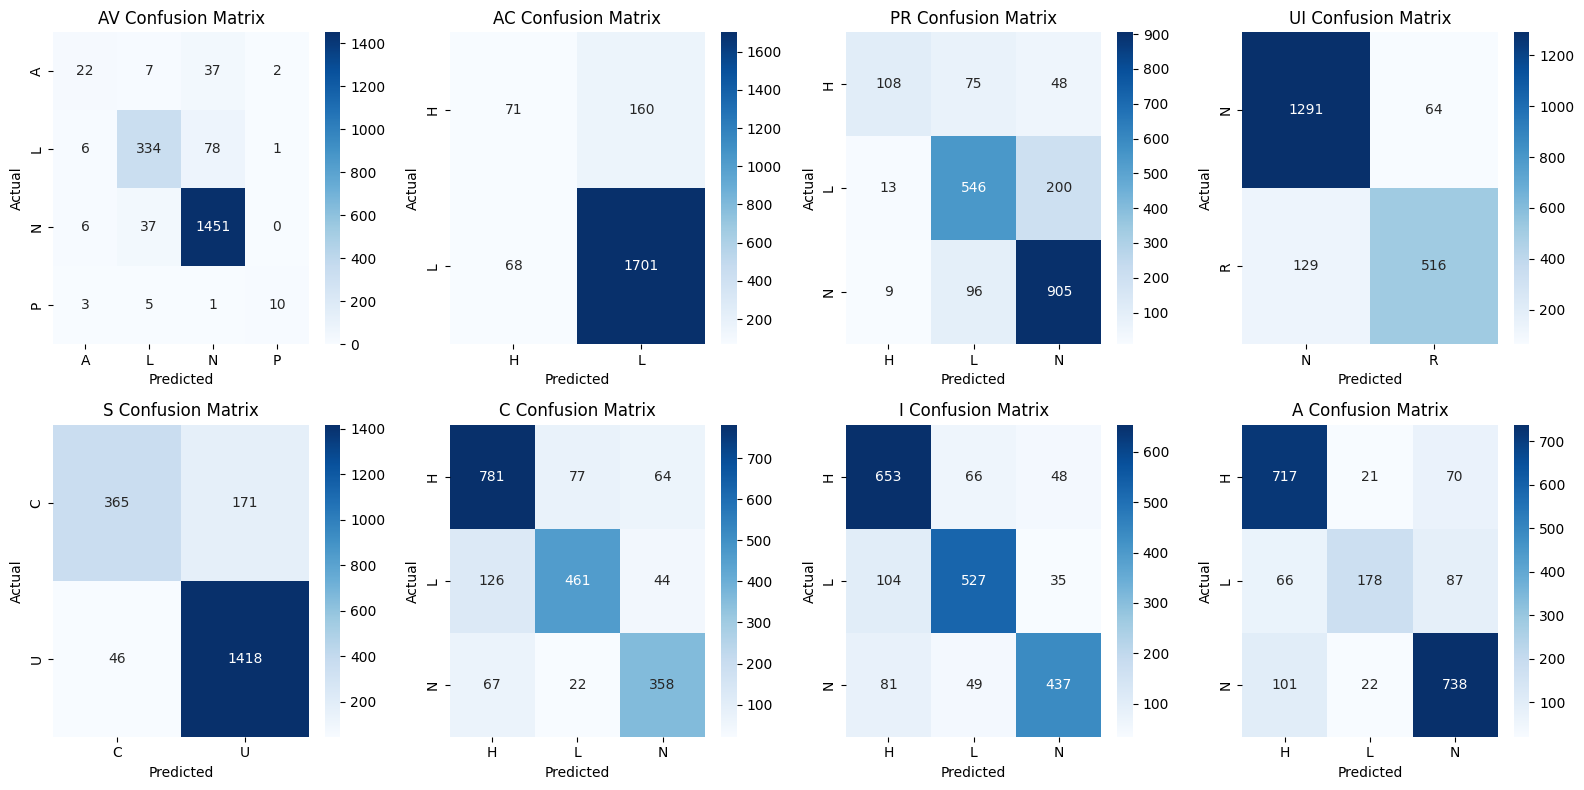

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, metric in zip(axes.flat, metrics):
    cm = confusion_matrix(all_true[metric], all_preds[metric])
    labels = sorted(label_mappings[metric], key=label_mappings[metric].get)

    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, ax=ax, cmap="Blues")

    ax.set_title(f"{metric} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 7. Approach 2 — Independent CVSS Metric Prediction

The second approach treats each CVSS v3.1 Base Metric as an independent classification task. Instead of using a single DistilBERT model to  predict all eight metrics, a separate DistilBERT model is applied for each metric. Each model uses the same CVE descriptions and the same training, validation, and test datasets, but is trained only on its corresponding metric. The eight independent predictions are then combined to reconstruct the complete CVSS v3.1 Base Vector for further evaluation.

### 7.1 Model Preparation and Training Pipeline

This section describes the common training and evaluation pipeline applied independently to each of the eight CVSS v3.1 Base Metrics. For a selected metric, the corresponding CVE descriptions and metric-specific labels are prepared and tokenized using the same preprocessing procedure. A separate DistilBERT sequence classification model is then initialized with the appropriate number of output classes and trained using the same training configuration as the other metrics. The trained model is evaluated on its corresponding test set using accuracy, macro-precision, macro-recall, and macro-F1. This procedure is implemented as a reusable pipeline and repeated independently for all eight CVSS metrics.

#### 7.1.1 Prepare Metric-Specific Data

This step creates separate training, validation, and test datasets containing the CVE descriptions and labels for the selected CVSS metric. The previously defined tokenizer is then applied to convert the descriptions into DistilBERT inputs.

In [30]:
# Create a metric-specific dataset containing text and labels
def prepare_metric_dataset(metric, df):
    return Dataset.from_pandas(
        df[["cleaned_description", f"{metric}_label"]].rename(
            columns={
                "cleaned_description": "text",
                f"{metric}_label": "labels"
            }
        ),
        preserve_index=False
    )

In [31]:
# Prepare and tokenize train, validation, and test datasets
def prepare_metric_data(metric):

    train_data = prepare_metric_dataset(metric, train_df)
    val_data = prepare_metric_dataset(metric, val_df)
    test_data = prepare_metric_dataset(metric, test_df)

    train_data = train_data.map(tokenize_function, batched=True)
    val_data = val_data.map(tokenize_function, batched=True)
    test_data = test_data.map(tokenize_function, batched=True)

    train_data = train_data.remove_columns(["text"])
    val_data = val_data.remove_columns(["text"])
    test_data = test_data.remove_columns(["text"])

    return train_data, val_data, test_data

#### 7.1.2 Initialize the Model

This function initializes a DistilBERT sequence classification model for the selected CVSS metric. The number of output classes is determined by the corresponding metric label mapping.

In [32]:
# Initialize a separate pretrained DistilBERT classifier for the selected CVSS metric
def create_metric_model(metric):
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_mappings[metric])
    )

#### 7.1.3 Define Training Configuration

This function defines the same training configuration as the first approach used for each independent DistilBERT model, including the learning rate, batch size, number of epochs, evaluation strategy, and model selection based on validation loss.

In [33]:
# Define the training configuration for the selected CVSS metric
def create_metric_training_args(metric):

    return TrainingArguments(
        output_dir=f"./distilbert_independent_{metric}",

        eval_strategy="epoch",
        save_strategy="epoch",

        learning_rate=3e-5,

        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,

        num_train_epochs=5,

        weight_decay=0.01,

        load_best_model_at_end=True,

        metric_for_best_model="eval_loss",

        greater_is_better=False,

        fp16=torch.cuda.is_available(),

        report_to="none"
    )

#### 7.1.4 Train the Metric-Specific Model

This step creates the Trainer using the metric-specific model, training configuration, and training and validation datasets, and then fine-tunes the model on the CVSS metric.

In [34]:
# Fine-tune the metric-specific DistilBERT model using the training and validation datasets
def train_metric_model(metric, train_data, val_data):

    model = create_metric_model(metric)
    args = create_metric_training_args(metric)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_data,
        eval_dataset=val_data,
        processing_class=tokenizer,
        data_collator=data_collator
    )

    trainer.train()

    return model, trainer

#### 7.1.5 Apply the Training Pipeline

This function combines data preparation, model initialization, training configuration, and model training into a reusable pipeline that can be applied independently to each of the eight CVSS metrics.

In [35]:
# Apply the complete training pipeline independently to the selected CVSS metric
def train_metric(metric):

    train_data, val_data, test_data = prepare_metric_data(metric)
    model, trainer = train_metric_model(metric, train_data, val_data)

    return model, test_data, trainer

#### 7.1.6 Evaluate the Model

This function evaluates a trained metric-specific DistilBERT model using the test set. Accuracy, macro-precision, macro-recall, and macro-F1 are calculated for the selected CVSS metric.

In [36]:
# Evaluate the trained metric-specific model on the test set
def evaluate_metric(trainer, test_data, metric):

    predictions = trainer.predict(test_data).predictions.argmax(axis=1)
    true_labels = test_df[f"{metric}_label"].values

    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average="macro", zero_division=0)
    accuracy = accuracy_score(true_labels, predictions)

    print(f"{metric} Results")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

### 7.2 Independent CVSS Metric Prediction

This section presents the eight independent CVSS metric prediction tasks. A separate DistilBERT classifier is trained for each CVSS v3.1 Base Metric: Attack Vector (AV), Attack Complexity (AC), Privileges Required (PR), User Interaction (UI), Scope (S), Confidentiality (C), Integrity (I), and Availability (A).

#### 7.2.1 Attack Vector (AV)

In [37]:
AV_model, AV_test, AV_trainer = train_metric("AV")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'loss': '0.4267', 'grad_norm': '4.641', 'learning_rate': '2.701e-05', 'epoch': '0.5'}
{'loss': '0.3213', 'grad_norm': '4.865', 'learning_rate': '2.401e-05', 'epoch': '1'}
{'eval_loss': '0.3123', 'eval_runtime': '5.339', 'eval_samples_per_second': '374.6', 'eval_steps_per_second': '23.41', 'epoch': '1'}


...

{'loss': '0.1252', 'grad_norm': '1.947', 'learning_rate': '9.006e-06', 'epoch': '3.5'}
{'loss': '0.1356', 'grad_norm': '7.972', 'learning_rate': '6.006e-06', 'epoch': '4'}
{'eval_loss': '0.3751', 'eval_runtime': '2.717', 'eval_samples_per_second': '736.1', 'eval_steps_per_second': '46.01', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.085', 'grad_norm': '10.51', 'learning_rate': '3.006e-06', 'epoch': '4.5'}
{'loss': '0.09833', 'grad_norm': '0.8355', 'learning_rate': '6e-09', 'epoch': '5'}
{'eval_loss': '0.4085', 'eval_runtime': '2.894', 'eval_samples_per_second': '691.1', 'eval_steps_per_second': '43.2', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '503.9', 'train_samples_per_second': '158.8', 'train_steps_per_second': '9.923', 'train_loss': '0.2063', 'epoch': '5'}


In [38]:
AV_results = evaluate_metric(AV_trainer, AV_test, "AV")

AV Results
Accuracy : 0.9165
Precision: 0.8300
Recall   : 0.7346
F1-Score : 0.7730


#### 7.2.2 Attack Complexity (AC)

In [39]:
AC_model, AC_test, AC_trainer = train_metric("AC")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'loss': '0.3534', 'grad_norm': '3.868', 'learning_rate': '2.701e-05', 'epoch': '0.5'}
{'loss': '0.2997', 'grad_norm': '1.521', 'learning_rate': '2.401e-05', 'epoch': '1'}
{'eval_loss': '0.2661', 'eval_runtime': '2.675', 'eval_samples_per_second': '747.5', 'eval_steps_per_second': '46.72', 'epoch': '1'}


...

{'loss': '0.1395', 'grad_norm': '0.4555', 'learning_rate': '9.006e-06', 'epoch': '3.5'}
{'loss': '0.1434', 'grad_norm': '9.782', 'learning_rate': '6.006e-06', 'epoch': '4'}
{'eval_loss': '0.4081', 'eval_runtime': '2.673', 'eval_samples_per_second': '748.1', 'eval_steps_per_second': '46.76', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.09142', 'grad_norm': '4.933', 'learning_rate': '3.006e-06', 'epoch': '4.5'}
{'loss': '0.09905', 'grad_norm': '4.136', 'learning_rate': '6e-09', 'epoch': '5'}
{'eval_loss': '0.4844', 'eval_runtime': '2.793', 'eval_samples_per_second': '716', 'eval_steps_per_second': '44.75', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '460.7', 'train_samples_per_second': '173.7', 'train_steps_per_second': '10.85', 'train_loss': '0.2058', 'epoch': '5'}


In [40]:
AC_results = evaluate_metric(AC_trainer, AC_test, "AC")

AC Results
Accuracy : 0.8965
Precision: 0.8013
Recall   : 0.5858
F1-Score : 0.6164


#### 7.2.3 Privileges Required (PR)

In [41]:
PR_model, PR_test, PR_trainer = train_metric("PR")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'loss': '0.7449', 'grad_norm': '4.264', 'learning_rate': '2.701e-05', 'epoch': '0.5'}
{'loss': '0.5851', 'grad_norm': '5.71', 'learning_rate': '2.401e-05', 'epoch': '1'}
{'eval_loss': '0.5321', 'eval_runtime': '2.671', 'eval_samples_per_second': '748.9', 'eval_steps_per_second': '46.8', 'epoch': '1'}


...

{'loss': '0.2561', 'grad_norm': '23.86', 'learning_rate': '9.006e-06', 'epoch': '3.5'}
{'loss': '0.2703', 'grad_norm': '6.789', 'learning_rate': '6.006e-06', 'epoch': '4'}
{'eval_loss': '0.6809', 'eval_runtime': '2.674', 'eval_samples_per_second': '748.1', 'eval_steps_per_second': '46.76', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2004', 'grad_norm': '22.23', 'learning_rate': '3.006e-06', 'epoch': '4.5'}
{'loss': '0.1899', 'grad_norm': '17.58', 'learning_rate': '6e-09', 'epoch': '5'}
{'eval_loss': '0.772', 'eval_runtime': '2.842', 'eval_samples_per_second': '703.6', 'eval_steps_per_second': '43.98', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '507.5', 'train_samples_per_second': '157.6', 'train_steps_per_second': '9.851', 'train_loss': '0.3978', 'epoch': '5'}


In [42]:
PR_results = evaluate_metric(PR_trainer, PR_test, "PR")

PR Results
Accuracy : 0.7835
Precision: 0.8188
Recall   : 0.7081
F1-Score : 0.7410


#### 7.2.4 User Interaction (UI)

In [43]:
UI_model, UI_test, UI_trainer = train_metric("UI")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'loss': '0.3448', 'grad_norm': '4.159', 'learning_rate': '2.701e-05', 'epoch': '0.5'}
{'loss': '0.285', 'grad_norm': '2.782', 'learning_rate': '2.401e-05', 'epoch': '1'}
{'eval_loss': '0.2728', 'eval_runtime': '2.67', 'eval_samples_per_second': '749', 'eval_steps_per_second': '46.81', 'epoch': '1'}


...

{'loss': '0.1179', 'grad_norm': '16.49', 'learning_rate': '9.006e-06', 'epoch': '3.5'}
{'loss': '0.1403', 'grad_norm': '12.24', 'learning_rate': '6.006e-06', 'epoch': '4'}
{'eval_loss': '0.3779', 'eval_runtime': '2.689', 'eval_samples_per_second': '743.7', 'eval_steps_per_second': '46.48', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.09722', 'grad_norm': '0.4545', 'learning_rate': '3.006e-06', 'epoch': '4.5'}
{'loss': '0.09375', 'grad_norm': '3.341', 'learning_rate': '6e-09', 'epoch': '5'}
{'eval_loss': '0.4353', 'eval_runtime': '2.659', 'eval_samples_per_second': '752.1', 'eval_steps_per_second': '47', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '489.9', 'train_samples_per_second': '163.3', 'train_steps_per_second': '10.21', 'train_loss': '0.191', 'epoch': '5'}


In [44]:
UI_results = evaluate_metric(UI_trainer, UI_test, "UI")

UI Results
Accuracy : 0.9080
Precision: 0.9035
Recall   : 0.8830
F1-Score : 0.8921


#### 7.2.5 Scope (S)

In [45]:
S_model, S_test, S_trainer = train_metric("S")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'loss': '0.3805', 'grad_norm': '1.737', 'learning_rate': '2.701e-05', 'epoch': '0.5'}
{'loss': '0.3192', 'grad_norm': '3.25', 'learning_rate': '2.401e-05', 'epoch': '1'}
{'eval_loss': '0.3084', 'eval_runtime': '2.701', 'eval_samples_per_second': '740.4', 'eval_steps_per_second': '46.27', 'epoch': '1'}


...

{'loss': '0.1212', 'grad_norm': '10.31', 'learning_rate': '9.006e-06', 'epoch': '3.5'}
{'loss': '0.1333', 'grad_norm': '4.814', 'learning_rate': '6.006e-06', 'epoch': '4'}
{'eval_loss': '0.5035', 'eval_runtime': '2.714', 'eval_samples_per_second': '737', 'eval_steps_per_second': '46.06', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.08442', 'grad_norm': '0.1245', 'learning_rate': '3.006e-06', 'epoch': '4.5'}
{'loss': '0.08649', 'grad_norm': '0.07742', 'learning_rate': '6e-09', 'epoch': '5'}
{'eval_loss': '0.5834', 'eval_runtime': '2.694', 'eval_samples_per_second': '742.5', 'eval_steps_per_second': '46.41', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '470.5', 'train_samples_per_second': '170', 'train_steps_per_second': '10.63', 'train_loss': '0.2046', 'epoch': '5'}


In [46]:
S_results = evaluate_metric(S_trainer, S_test, "S")

S Results
Accuracy : 0.8880
Precision: 0.8681
Recall   : 0.8383
F1-Score : 0.8515


#### 7.2.6 Confidentiality (C)

In [47]:
C_model, C_test, C_trainer = train_metric("C")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'loss': '0.6894', 'grad_norm': '5.416', 'learning_rate': '2.701e-05', 'epoch': '0.5'}
{'loss': '0.5465', 'grad_norm': '4.704', 'learning_rate': '2.401e-05', 'epoch': '1'}
{'eval_loss': '0.4916', 'eval_runtime': '2.847', 'eval_samples_per_second': '702.6', 'eval_steps_per_second': '43.91', 'epoch': '1'}


...

{'loss': '0.2566', 'grad_norm': '12.11', 'learning_rate': '9.006e-06', 'epoch': '3.5'}
{'loss': '0.2489', 'grad_norm': '4.958', 'learning_rate': '6.006e-06', 'epoch': '4'}
{'eval_loss': '0.6229', 'eval_runtime': '2.923', 'eval_samples_per_second': '684.1', 'eval_steps_per_second': '42.76', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.187', 'grad_norm': '5.684', 'learning_rate': '3.006e-06', 'epoch': '4.5'}
{'loss': '0.191', 'grad_norm': '11.43', 'learning_rate': '6e-09', 'epoch': '5'}
{'eval_loss': '0.689', 'eval_runtime': '2.673', 'eval_samples_per_second': '748.3', 'eval_steps_per_second': '46.77', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '492.6', 'train_samples_per_second': '162.4', 'train_steps_per_second': '10.15', 'train_loss': '0.3698', 'epoch': '5'}


In [48]:
C_results = evaluate_metric(C_trainer, C_test, "C")

C Results
Accuracy : 0.8010
Precision: 0.8023
Recall   : 0.7882
F1-Score : 0.7929


#### 7.2.7 Integrity (I)

In [49]:
I_model, I_test, I_trainer = train_metric("I")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'loss': '0.6857', 'grad_norm': '3.546', 'learning_rate': '2.701e-05', 'epoch': '0.5'}
{'loss': '0.5422', 'grad_norm': '6.017', 'learning_rate': '2.401e-05', 'epoch': '1'}
{'eval_loss': '0.5094', 'eval_runtime': '2.679', 'eval_samples_per_second': '746.6', 'eval_steps_per_second': '46.66', 'epoch': '1'}


...

{'loss': '0.2621', 'grad_norm': '4.374', 'learning_rate': '9.006e-06', 'epoch': '3.5'}
{'loss': '0.2621', 'grad_norm': '12.66', 'learning_rate': '6.006e-06', 'epoch': '4'}
{'eval_loss': '0.6184', 'eval_runtime': '2.683', 'eval_samples_per_second': '745.4', 'eval_steps_per_second': '46.59', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.193', 'grad_norm': '17.37', 'learning_rate': '3.006e-06', 'epoch': '4.5'}
{'loss': '0.2068', 'grad_norm': '9.036', 'learning_rate': '6e-09', 'epoch': '5'}
{'eval_loss': '0.6894', 'eval_runtime': '2.697', 'eval_samples_per_second': '741.5', 'eval_steps_per_second': '46.34', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '472', 'train_samples_per_second': '169.5', 'train_steps_per_second': '10.59', 'train_loss': '0.3769', 'epoch': '5'}


In [50]:
I_results = evaluate_metric(I_trainer, I_test, "I")

I Results
Accuracy : 0.8030
Precision: 0.8048
Recall   : 0.8030
F1-Score : 0.8026


#### 7.2.8 Availability (A)

In [51]:
A_model, A_test, A_trainer = train_metric("A")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'loss': '0.6399', 'grad_norm': '3.288', 'learning_rate': '2.701e-05', 'epoch': '0.5'}
{'loss': '0.5352', 'grad_norm': '3.449', 'learning_rate': '2.401e-05', 'epoch': '1'}
{'eval_loss': '0.5054', 'eval_runtime': '2.711', 'eval_samples_per_second': '737.7', 'eval_steps_per_second': '46.1', 'epoch': '1'}


...

{'loss': '0.2873', 'grad_norm': '6.85', 'learning_rate': '9.006e-06', 'epoch': '3.5'}
{'loss': '0.2775', 'grad_norm': '7.11', 'learning_rate': '6.006e-06', 'epoch': '4'}
{'eval_loss': '0.6192', 'eval_runtime': '2.685', 'eval_samples_per_second': '745', 'eval_steps_per_second': '46.56', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2144', 'grad_norm': '11.68', 'learning_rate': '3.006e-06', 'epoch': '4.5'}
{'loss': '0.221', 'grad_norm': '4.659', 'learning_rate': '6e-09', 'epoch': '5'}
{'eval_loss': '0.6667', 'eval_runtime': '2.676', 'eval_samples_per_second': '747.3', 'eval_steps_per_second': '46.71', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '487.9', 'train_samples_per_second': '164', 'train_steps_per_second': '10.25', 'train_loss': '0.3816', 'epoch': '5'}


In [52]:
A_results = evaluate_metric(A_trainer, A_test, "A")

A Results
Accuracy : 0.8200
Precision: 0.8333
Recall   : 0.7614
F1-Score : 0.7826


### 7.3 Metrics Evaluation

This section evaluates the performance of the eight independently trained DistilBERT classifiers on the CVSS v3.1 Base Metrics. The evaluation considers overall classification performance as well as the performance of each individual metric using accuracy, macro-precision, macro-recall, and macro-F1. Confusion matrices are also used to examine the distribution of correct and incorrect predictions across the classes of each metric.

In [53]:
independent_preds = {
    "AV": AV_trainer.predict(AV_test).predictions.argmax(axis=1),
    "AC": AC_trainer.predict(AC_test).predictions.argmax(axis=1),
    "PR": PR_trainer.predict(PR_test).predictions.argmax(axis=1),
    "UI": UI_trainer.predict(UI_test).predictions.argmax(axis=1),
    "S": S_trainer.predict(S_test).predictions.argmax(axis=1),
    "C": C_trainer.predict(C_test).predictions.argmax(axis=1),
    "I": I_trainer.predict(I_test).predictions.argmax(axis=1),
    "A": A_trainer.predict(A_test).predictions.argmax(axis=1)
}

#### 7.3.1 Overall Performance

The independent approach achieved 85.21% accuracy, with 83.28% precision, 76.28% recall, and 78.15% F1-score across the eight CVSS metrics.


In [54]:
scores = []

for m in metrics:

    y_true = test_df[f"{m}_label"]
    y_pred = independent_preds[m]

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    scores.append([accuracy, precision, recall, f1])

overall = np.mean(scores, axis=0)
independent_overall_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": overall
})

display(independent_overall_results.round(4))

,Metric,Score
0,Accuracy,0.8521
1,Precision,0.8328
2,Recall,0.7628
3,F1-Score,0.7815


#### 7.3.2 Performance by CVSS Metric

Performance varied across the metrics. AV achieved the highest accuracy (91.65%), while PR had the lowest (78.35%). Overall, AV, UI, and AC showed stronger performance, whereas I, PR, and C were more challenging.

In [55]:
metric_results = []

for m in metrics:

    y_true = test_df[f"{m}_label"]
    y_pred = independent_preds[m]

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    metric_results.append([m, accuracy, precision, recall, f1])

metric_results_df = pd.DataFrame(
    metric_results,
    columns=["Metric", "Accuracy", "Precision", "Recall", "F1-Score"]
)

display(metric_results_df.round(4))

,Metric,Accuracy,Precision,Recall,F1-Score
0,AV,0.9165,0.8300,0.7346,0.7730
1,AC,0.8965,0.8013,0.5858,0.6164
2,PR,0.7835,0.8188,0.7081,0.7410
3,UI,0.9080,0.9035,0.8830,0.8921
4,S,0.8880,0.8681,0.8383,0.8515
5,C,0.8010,0.8023,0.7882,0.7929
6,I,0.8030,0.8048,0.8030,0.8026
7,A,0.8200,0.8333,0.7614,0.7826


#### 7.3.3 Confusion Matrices

The model performs very well on User Interaction (AV) and Scope (UI) , getting most predictions right. It has a bit more trouble with Privileges Required (PR) and Confidentiality (C) , sometimes mixing up similar categories like PR:L and PR:N.

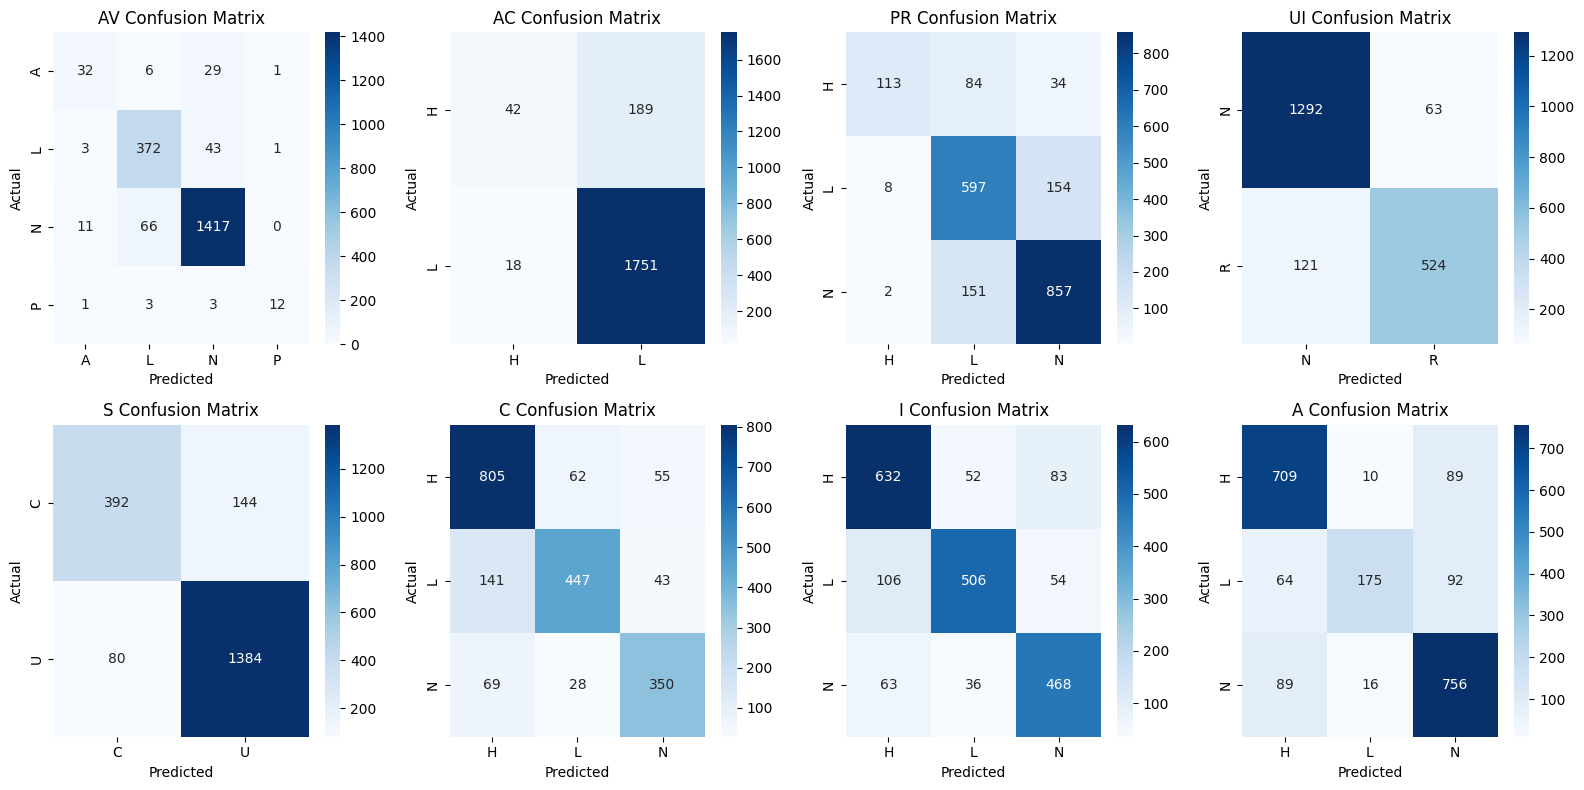

In [56]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, m in zip(axes.flat, metrics):

    cm = confusion_matrix(test_df[f"{m}_label"], independent_preds[m])

    labels = sorted(label_mappings[m], key=label_mappings[m].get)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues", ax=ax)
    ax.set_title(f"{m} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 8. Research Question 1 — Multi-Task vs. Independent DistilBERT for CVSS Metric Prediction

This section compares the predictive performance of the multi-task and independent DistilBERT approaches for the eight CVSS v3.1 Base Metrics. Both approaches are evaluated using the same test set and the same evaluation metrics: accuracy, macro-precision, macro-recall, and macro-F1. The comparison is conducted at both the overall level and for each individual CVSS metric.

### 8.1 Overall Comparison

This comparison summarizes the overall performance of the two approaches across all eight CVSS Base Metrics. The independent DistilBERT approach achieves higher scores than the multi-task model across all four evaluation measures.

**Key Findings**

- Independent DistilBERT performs better on all four overall measures.
- Macro-F1 increases from 0.7760 to 0.7815.
- Macro-recall increases from 0.7553 to 0.7628.

In [57]:
comparison = pd.DataFrame({
    "Metric": multi_task_overall_results["Metric"],
    "Multi-Task DistilBERT": multi_task_overall_results["Score"],
    "Independent DistilBERT": independent_overall_results["Score"]
})

display(comparison.round(4))

,Metric,Multi-Task DistilBERT,Independent DistilBERT
0,Accuracy,0.8492,0.8521
1,Precision,0.8137,0.8328
2,Recall,0.7553,0.7628
3,F1-Score,0.7760,0.7815


### 8.2 Metric-Level Comparison

This section compares the two approaches for each CVSS Base Metric to determine whether the overall performance difference is consistent across independent metrics.

**Key Findings**

- Independent DistilBERT achieved higher accuracy on 6 of 8 CVSS metrics, outperforming Multi-Task on AV, AC, PR, UI, C and A.
- Multi-Task learning achieved stronger recall on 3 of 8 metrics, particularly AC, C, and I.
- Independent learning generally achieved higher precision, outperforming Multi-Task on 6 of 8 metrics; Multi-Task was better only for S and I.
- F1-score results were mixed: Multi-Task performed better on AC, C, and I while Independent performed better on AV, PR, UI, S, and A.
- Independent learning provided more consistent overall classification performance, particularly in accuracy and precision.

In [58]:
metric_comparison = pd.DataFrame({
    "Metric": metrics,

    "Multi-Task Accuracy": metric_accuracy["Accuracy"].values,
    "Independent Accuracy": metric_results_df["Accuracy"].values,

    "Multi-Task Precision": metric_accuracy["Precision"].values,
    "Independent Precision": metric_results_df["Precision"].values,

    "Multi-Task Recall": metric_accuracy["Recall"].values,
    "Independent Recall": metric_results_df["Recall"].values,

    "Multi-Task F1-Score": metric_accuracy["F1-Score"].values,
    "Independent F1-Score": metric_results_df["F1-Score"].values
})

display(metric_comparison.round(4))

,Metric,Multi-Task Accuracy,Independent Accuracy,Multi-Task Precision,Independent Precision,Multi-Task Recall,Independent Recall,Multi-Task F1-Score,Independent F1-Score
0,AV,0.9085,0.9165,0.7905,0.8300,0.6545,0.7346,0.7063,0.7730
1,AC,0.8860,0.8965,0.7124,0.8013,0.6345,0.5858,0.6605,0.6164
2,PR,0.7795,0.7835,0.7924,0.8188,0.6943,0.7081,0.7250,0.7410
3,UI,0.9035,0.9080,0.8994,0.9035,0.8764,0.8830,0.8864,0.8921
4,S,0.8915,0.8880,0.8902,0.8681,0.8248,0.8383,0.8499,0.8515
5,C,0.8000,0.8010,0.7978,0.8023,0.7929,0.7882,0.7941,0.7929
6,I,0.8085,0.8030,0.8135,0.8048,0.8045,0.8030,0.8079,0.8026
7,A,0.8165,0.8200,0.8137,0.8333,0.7608,0.7614,0.7777,0.7826


### 8.3 Confusion Matrix Analysis

This section compares the two approaches for each CVSS Base Metric to determine whether the overall performance difference is consistent across individual metrics.

**Key Findings**

- Independent DistilBERT generally produces stronger class separation, with slightly higher diagonal performance across most CVSS base metrics.
- Both approaches perform well on dominant classes such as AV, UI, S, and the H/N classes of C, I, and A, while minority classes show more misclassification.

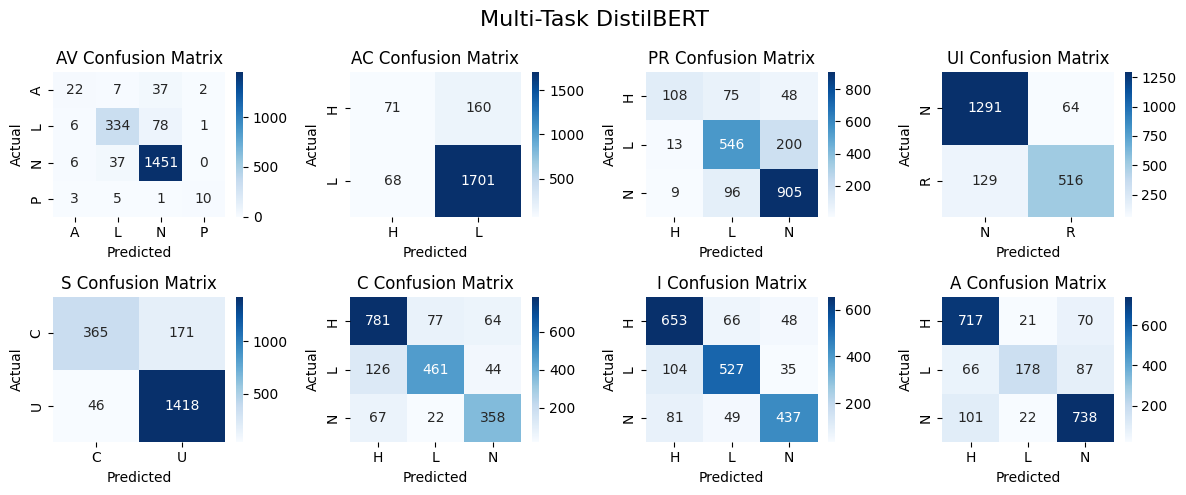

In [59]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 4, figsize=(12, 5))

for ax, metric in zip(axes.flat, metrics):
    cm = confusion_matrix(all_true[metric], all_preds[metric])
    labels = sorted(label_mappings[metric], key=label_mappings[metric].get)

    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, ax=ax, cmap="Blues")

    ax.set_title(f"{metric} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Multi-Task DistilBERT", fontsize=16)
plt.tight_layout()
plt.show()

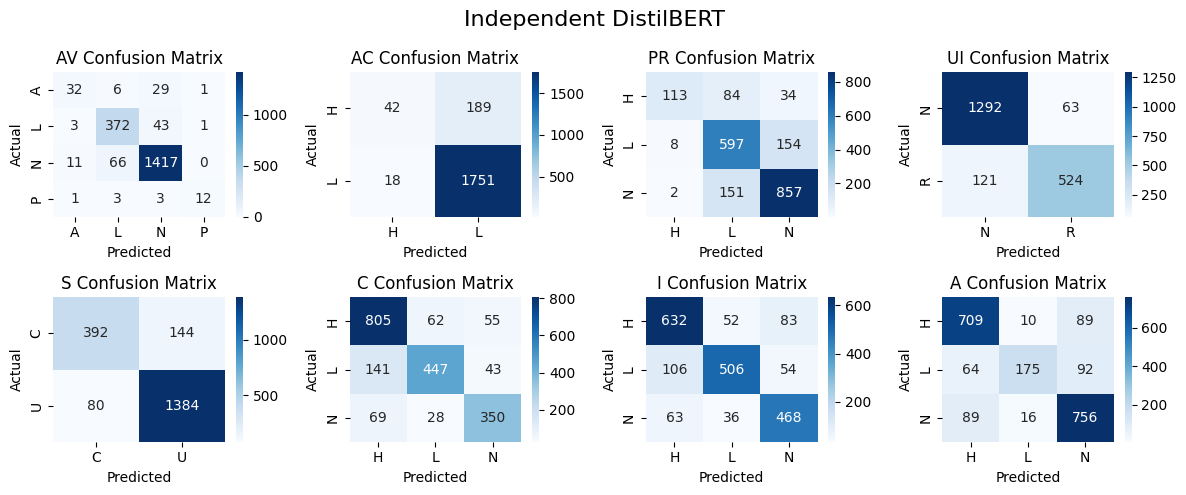

In [60]:
fig, axes = plt.subplots(2, 4, figsize=(12,5))

for ax, metric in zip(axes.flat, metrics):

    cm = confusion_matrix(test_df[f"{metric}_label"], independent_preds[metric])

    labels = sorted(label_mappings[metric], key=label_mappings[metric].get)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues", ax=ax)
    ax.set_title(f"{metric} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Independent DistilBERT", fontsize=16)
plt.tight_layout()
plt.show()

### 8.4 Conclusion and Answer to RQ1

RQ1: Does multi-task learning improve the prediction of the eight CVSS v3.1 Base Metrics compared with independently trained DistilBERT models?

Answer: No. The independent DistilBERT approach achieves better overall performance than the multi-task model. Across the eight CVSS Base Metrics, the independent approach improves the macro-averaged Accuracy from 0.8492 to 0.8521, Precision from 0.8137 to 0.8328, Recall from 0.7553 to 0.7628, and F1-Score from 0.7760 to 0.7815. At the metric level, independent models achieve higher precision on 6 of 8 metrics, while the multi-task model performs slightly better on Integrity (I) and Scope (S).

## 9. Research Question 2 — Severity Classification

This section evaluates whether the choice between multi-task and independent CVSS metric prediction affects the resulting CVSS severity classification. The predicted values of the eight Base Metrics are first combined into a complete CVSS v3.1 Base Vector. The corresponding CVSS base score and severity level are then calculated and compared with the ground-truth severity labels for Low, Medium, High, and Critical vulnerabilities.

### 9.1 Severity Classification from Multi-Task DistilBERT Predictions

The eight Base Metrics predicted by the multi-task DistilBERT model are converted back to their original CVSS values and combined to construct a CVSS v3.1 Base Vector for each test sample. The CVSS base score and corresponding severity level are then calculated from the reconstructed vector using an open source python library ([cvsslib, 2020](https://pypi.org/project/cvsslib/#history)) for comparison with the ground-truth severity.

In [63]:
from cvsslib import cvss31, calculate_vector

# Convert numerical predictions back to their original CVSS metric values
multi_task_pred_values = {}
for metric in metrics:
    multi_task_pred_values[metric] = [
        inverse_mappings[metric][int(x)]
        for x in all_preds[metric]
    ]

# Create a results containing ground-truth and predicted metrics
multi_task_severity_results = test_df[["cve_id", "cvss_base_score", "severity"]].copy()

for metric in metrics:
    multi_task_severity_results[f"pred_{metric}"] = multi_task_pred_values[metric]

multi_task_severity_results.head()

,cve_id,cvss_base_score,severity,pred_AV,pred_AC,pred_PR,pred_UI,pred_S,pred_C,pred_I,pred_A
19915,CVE-2025-30817,5.4,Medium,N,L,N,N,U,N,L,N
14605,CVE-2024-8889,9.3,Critical,N,L,N,N,U,N,H,H
9893,CVE-2024-36443,7.6,High,N,L,N,N,U,H,N,N
4128,CVE-2025-30946,4.3,Medium,N,L,N,R,U,N,L,N
14799,CVE-2026-21678,7.8,High,L,L,N,R,U,H,H,H


In [64]:
# Build a complete CVSS v3.1 Base Vector from the eight predicted metrics
def build_cvss31_vector(row):
    return (
        f"CVSS:3.1/"
        f"AV:{row['pred_AV']}/"
        f"AC:{row['pred_AC']}/"
        f"PR:{row['pred_PR']}/"
        f"UI:{row['pred_UI']}/"
        f"S:{row['pred_S']}/"
        f"C:{row['pred_C']}/"
        f"I:{row['pred_I']}/"
        f"A:{row['pred_A']}"
    )


# Calculate the CVSS v3.1 Base Score from the reconstructed vector
def calculate_cvss_score(vector):
    return calculate_vector(vector, cvss31)[0]

multi_task_severity_results["predicted_vector"] = (
    multi_task_severity_results.apply(
        build_cvss31_vector,
        axis=1
    )
)

multi_task_severity_results["predicted_score"] = (
    multi_task_severity_results["predicted_vector"]
    .apply(calculate_cvss_score)
)

multi_task_severity_results.head()

,cve_id,cvss_base_score,severity,pred_AV,pred_AC,pred_PR,pred_UI,pred_S,pred_C,pred_I,pred_A,predicted_vector,predicted_score
19915,CVE-2025-30817,5.4,Medium,N,L,N,N,U,N,L,N,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:L/A:N,5.3
14605,CVE-2024-8889,9.3,Critical,N,L,N,N,U,N,H,H,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:H/A:H,9.1
9893,CVE-2024-36443,7.6,High,N,L,N,N,U,H,N,N,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,7.5
4128,CVE-2025-30946,4.3,Medium,N,L,N,R,U,N,L,N,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:L/A:N,4.3
14799,CVE-2026-21678,7.8,High,L,L,N,R,U,H,H,H,CVSS:3.1/AV:L/AC:L/PR:N/UI:R/S:U/C:H/I:H/A:H,7.8


In [65]:
# Convert the predicted CVSS Base Score into a severity category
multi_task_severity_results["predicted_severity"] = (
    multi_task_severity_results["predicted_score"]
    .apply(get_severity)
)

# Display the ground-truth and predicted CVSS results
display(
    multi_task_severity_results[
        [
            "cvss_base_score",
            "severity",
            "predicted_vector",
            "predicted_score",
            "predicted_severity"
        ]
    ].head(10)
)

,cvss_base_score,severity,predicted_vector,predicted_score,predicted_severity
19915,5.4,Medium,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:L/A:N,5.3,Medium
14605,9.3,Critical,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:H/A:H,9.1,Critical
9893,7.6,High,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,7.5,High
4128,4.3,Medium,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:L/A:N,4.3,Medium
14799,7.8,High,CVSS:3.1/AV:L/AC:L/PR:N/UI:R/S:U/C:H/I:H/A:H,7.8,High
5483,7.1,High,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:C/C:L/I:L/A:L,7.1,High
278,5.4,Medium,CVSS:3.1/AV:N/AC:L/PR:L/UI:N/S:U/C:H/I:N/A:N,6.5,Medium
17395,5.0,Medium,CVSS:3.1/AV:L/AC:L/PR:N/UI:R/S:U/C:N/I:N/A:L,3.3,Low
1692,8.1,High,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:C/C:H/I:H/A:N,9.3,Critical
13875,9.1,Critical,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:H/A:N,7.5,High


### 9.2 Severity Classification from Independent DistilBERT Predictions

The predictions from the eight independently trained DistilBERT models are combined using the same procedure. A CVSS v3.1 Base Vector is reconstructed for each test sample, and the resulting CVSS base score and severity level are calculated.

In [66]:
# Convert numerical predictions back to their original CVSS metric values
independent_pred_values = {}

for metric in metrics:
    independent_pred_values[metric] = [
        inverse_mappings[metric][int(x)]
        for x in independent_preds[metric]
    ]

# Create a results dataframe containing ground-truth and predicted metrics
independent_severity_results = test_df[["cve_id", "cvss_base_score", "severity"]].copy()

for metric in metrics:
    independent_severity_results[f"pred_{metric}"] = (
        independent_pred_values[metric]
    )

independent_severity_results.head()

,cve_id,cvss_base_score,severity,pred_AV,pred_AC,pred_PR,pred_UI,pred_S,pred_C,pred_I,pred_A
19915,CVE-2025-30817,5.4,Medium,N,L,L,N,U,N,L,N
14605,CVE-2024-8889,9.3,Critical,N,L,N,N,U,N,H,H
9893,CVE-2024-36443,7.6,High,N,L,N,N,U,H,N,N
4128,CVE-2025-30946,4.3,Medium,N,L,N,R,U,N,L,N
14799,CVE-2026-21678,7.8,High,L,L,N,R,U,H,H,H


In [67]:
# Build a complete CVSS v3.1 Base Vector from the predicted metrics
independent_severity_results["predicted_vector"] = (
    independent_severity_results.apply(
        build_cvss31_vector,
        axis=1
    )
)

# Calculate the CVSS v3.1 Base Score from the reconstructed vector
independent_severity_results["predicted_score"] = (
    independent_severity_results["predicted_vector"]
    .apply(calculate_cvss_score)
)

independent_severity_results.head()

,cve_id,cvss_base_score,severity,pred_AV,pred_AC,pred_PR,pred_UI,pred_S,pred_C,pred_I,pred_A,predicted_vector,predicted_score
19915,CVE-2025-30817,5.4,Medium,N,L,L,N,U,N,L,N,CVSS:3.1/AV:N/AC:L/PR:L/UI:N/S:U/C:N/I:L/A:N,4.3
14605,CVE-2024-8889,9.3,Critical,N,L,N,N,U,N,H,H,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:H/A:H,9.1
9893,CVE-2024-36443,7.6,High,N,L,N,N,U,H,N,N,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,7.5
4128,CVE-2025-30946,4.3,Medium,N,L,N,R,U,N,L,N,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:L/A:N,4.3
14799,CVE-2026-21678,7.8,High,L,L,N,R,U,H,H,H,CVSS:3.1/AV:L/AC:L/PR:N/UI:R/S:U/C:H/I:H/A:H,7.8


In [68]:
# Convert the predicted CVSS Base Score into a severity category
independent_severity_results["predicted_severity"] = (
    independent_severity_results["predicted_score"]
    .apply(get_severity)
)

# Display the ground-truth and predicted CVSS results
display(
    independent_severity_results[
        [
            "cvss_base_score",
            "severity",
            "predicted_vector",
            "predicted_score",
            "predicted_severity"
        ]
    ].head(10)
)

,cvss_base_score,severity,predicted_vector,predicted_score,predicted_severity
19915,5.4,Medium,CVSS:3.1/AV:N/AC:L/PR:L/UI:N/S:U/C:N/I:L/A:N,4.3,Medium
14605,9.3,Critical,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:H/A:H,9.1,Critical
9893,7.6,High,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,7.5,High
4128,4.3,Medium,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:L/A:N,4.3,Medium
14799,7.8,High,CVSS:3.1/AV:L/AC:L/PR:N/UI:R/S:U/C:H/I:H/A:H,7.8,High
5483,7.1,High,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:C/C:L/I:L/A:L,7.1,High
278,5.4,Medium,CVSS:3.1/AV:N/AC:L/PR:L/UI:N/S:U/C:H/I:N/A:N,6.5,Medium
17395,5.0,Medium,CVSS:3.1/AV:L/AC:L/PR:N/UI:R/S:U/C:H/I:N/A:H,7.1,High
1692,8.1,High,CVSS:3.1/AV:N/AC:L/PR:L/UI:R/S:C/C:H/I:H/A:H,9.0,Critical
13875,9.1,Critical,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:L/A:N,5.3,Medium


### 9.3  Comparison of Severity Classification Performance

This section compares the severity classifications from the multi-task and independent DistilBERT predictions. For each test sample, the eight predicted CVSS v3.1 Base Metrics are reconstructed into a Base Vector, from which the corresponding Base Score and severity level are calculated. The two approaches are then compared using overall performance measures and class-level analysis across the Low, Medium, High, and Critical severity levels.


#### 9.3.1 Overall Comparison

The overall comparison evaluates the severity classification performance of the multi-task and independent approaches using accuracy, macro-precision, macro-recall, and macro-F1. These measures summarize performance across all four severity categories.

**Key Findings**

- Independent DistilBERT achieves higher performance across all four evaluation measures.
- Accuracy increases from 67.25% to 68.45%.
- Macro-F1 increases from 59.43% to 60.35%.

In [69]:
# Calculate severity classification performance for both approaches
def evaluate_severity(results):

    valid = results["predicted_severity"].notna()

    y_true = results.loc[valid, "severity"]
    y_pred = results.loc[valid, "predicted_severity"]

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",zero_division=0)

    return [accuracy_score(y_true, y_pred), precision, recall, f1]

multi_task_severity = evaluate_severity(multi_task_severity_results)
independent_severity = evaluate_severity(independent_severity_results)

In [70]:
# Compare overall severity classification performance
severity_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Multi-Task DistilBERT": multi_task_severity,
    "Independent DistilBERT": independent_severity
})

display(severity_comparison.round(4))

,Metric,Multi-Task DistilBERT,Independent DistilBERT
0,Accuracy,0.6725,0.6845
1,Precision,0.5943,0.6035
2,Recall,0.5775,0.5876
3,F1-Score,0.5744,0.5881


#### 9.3.2 Severity-Level Comparison

This analysis compares classification performance separately for the four CVSS severity levels: Low, Medium, High, and Critical. Per-class precision, recall, and F1-score are calculated for both approaches to identify severity categories that are easier or more difficult to classify.

**Key Findings**

- Medium severity performs best for both models, while Low severity performs the worst.
- Independent model is superior for Critical severity, delivering noticeably higher Precision, Recall, and F1 compared to Multi-Task

In [72]:
severity_labels = ["Low", "Medium", "High", "Critical"]

# Generate per-class performance for the Mult-Task model
multi_task_report = pd.DataFrame(
    classification_report(
        multi_task_severity_results["severity"],
        multi_task_severity_results["predicted_severity"],
        labels=severity_labels,
        output_dict=True,
        zero_division=0
    )
).T

# Generate per-class performance for the independent models
independent_report = pd.DataFrame(
    classification_report(
        independent_severity_results["severity"],
        independent_severity_results["predicted_severity"],
        labels=severity_labels,
        output_dict=True,
        zero_division=0
    )
).T

independent_report.head()

,precision,recall,f1-score,support
Low,0.500000,0.317308,0.388235,104.0000
Medium,0.786756,0.741015,0.763201,946.0000
High,0.652672,0.684913,0.668404,749.0000
Critical,0.474708,0.606965,0.532751,201.0000
accuracy,0.684500,0.684500,0.684500,0.6845


In [73]:
# Keep only the four severity levels
multi_task_report = multi_task_report.loc[severity_labels, ["precision", "recall", "f1-score"]]
independent_report = independent_report.loc[severity_labels, ["precision", "recall", "f1-score"]]

# Create comparison table
severity_level_comparison = pd.DataFrame({
    "Severity": severity_labels,
    "Multi-Task Precision": multi_task_report["precision"].values,
    "Independent Precision": independent_report["precision"].values,
    "Multi-Task Recall": multi_task_report["recall"].values,
    "Independent Recall": independent_report["recall"].values,
    "Multi-Task F1": multi_task_report["f1-score"].values,
    "Independent F1": independent_report["f1-score"].values
})

display(severity_level_comparison.round(4))

,Severity,Multi-Task Precision,Independent Precision,Multi-Task Recall,Independent Recall,Multi-Task F1,Independent F1
0,Low,0.5323,0.5000,0.3173,0.3173,0.3976,0.3882
1,Medium,0.7779,0.7868,0.7442,0.7410,0.7607,0.7632
2,High,0.6630,0.6527,0.6515,0.6849,0.6572,0.6684
3,Critical,0.4040,0.4747,0.5970,0.6070,0.4819,0.5328


#### 9.3.3 Confusion Matrix Analysis

Confusion matrices are used to examine class-level errors for the four severity categories. They show how often vulnerabilities from each actual severity level are correctly classified or assigned to another severity level by the multi-task and independent approaches.

**Key Findings**

- Both models correctly classify Medium severity most frequently, while Low severity is the most difficult class to identify.
- Misclassifications mainly occur between adjacent severity levels, particularly Medium with High and High with Critical.
- Independent DistilBERT improves High and Critical classification compared with Multi-Task learning.
- Overall severity classification improves slightly with Independent DistilBERT.

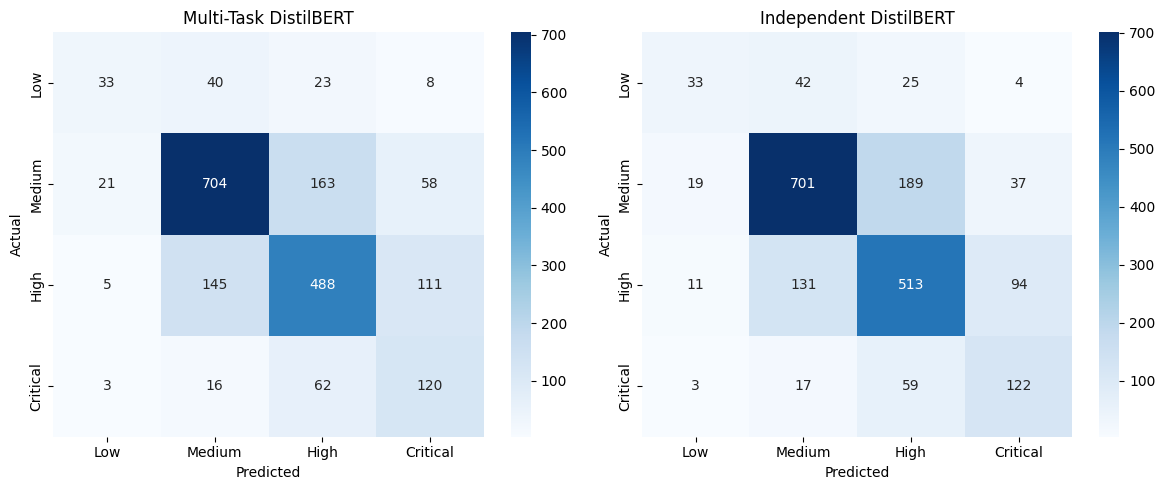

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Multi-Task DistilBERT
multi_task_cm = confusion_matrix(
    multi_task_severity_results["severity"],
    multi_task_severity_results["predicted_severity"],
    labels=severity_labels
)

sns.heatmap(multi_task_cm, annot=True, fmt="d", xticklabels=severity_labels, yticklabels=severity_labels, cmap="Blues", ax=axes[0])

axes[0].set_title("Multi-Task DistilBERT")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


# Independent DistilBERT
independent_cm = confusion_matrix(
    independent_severity_results["severity"],
    independent_severity_results["predicted_severity"],
    labels=severity_labels
)

sns.heatmap(independent_cm, annot=True, fmt="d", xticklabels=severity_labels, yticklabels=severity_labels, cmap="Blues", ax=axes[1])

axes[1].set_title("Independent DistilBERT")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 9.4 Conclusion and Answer to RQ2


RQ2: Does the choice between multi-task and independent prediction affect the accuracy of the resulting CVSS severity-level classification?

Answer: Yes. The independent DistilBERT approach achieves better overall severity classification performance than the multi-task approach. Accuracy increases from 0.6725 to 0.6845, while macro-F1 increases from 0.5744 to 0.5881. At the severity level, the independent approach also achieves higher F1-scores for Medium, High, and Critical categories.

## 10. Research Question 3 — CVSS Base Vector Reconstruction

This section evaluates how accurately the complete CVSS v3.1 Base Vector can be reconstructed from the predicted Base Metrics. For each test vulnerability, the eight predicted metrics are combined into a CVSS v3.1 Base Vector and compared with the corresponding ground-truth vector. A prediction is considered correct only when all eight Base Metrics match the ground-truth vector exactly.

### 10.1 Multi-Task DistilBERT Vector Reconstruction and Results

The CVSS v3.1 Base Vectors generated from the multi-task model predictions are compared with the ground-truth vectors. Exact vector accuracy is calculated as the proportion of test vulnerabilities for which all eight predicted Base Metrics exactly match the corresponding ground-truth vector.

In [75]:
# Calculate exact CVSS Base Vector accuracy
multi_task_vector_accuracy = (
    multi_task_severity_results["predicted_vector"]
    == test_df["cvss_vector"]
).mean()

print(f"Multi-Task Exact CVSS Vector Accuracy: {multi_task_vector_accuracy:.4f}")

Multi-Task Exact CVSS Vector Accuracy: 0.4180


In [76]:
# Calculate the average number of correctly reconstructed Base Metrics
multi_task_avg_correct = sum(
    multi_task_severity_results[f"pred_{m}"] == test_df[m]
    for m in metrics
).mean()

print(f"Multi-Task Average Metrics Correct: {multi_task_avg_correct:.2f}/8")

Multi-Task Average Metrics Correct: 6.79/8


In [77]:
# Calculate CVSS Base Score MAE
multi_task_score_mae = mean_absolute_error(
    test_df["cvss_base_score"],
    multi_task_severity_results["predicted_score"]
)

print(f"Multi-Task CVSS Base Score MAE: {multi_task_score_mae:.4f}")

Multi-Task CVSS Base Score MAE: 0.9467


### 10.2 Independent DistilBERT Vector Reconstruction

The eight Base Metrics predicted by the multi-task DistilBERT model are combined to form a complete CVSS v3.1 Base Vector. The reconstructed vectors are compared with the ground-truth vectors to measure exact vector agreement, partial metric agreement, and the resulting CVSS Base Score error.

In [78]:
# Calculate exact CVSS Base Vector accuracy
independent_vector_accuracy = (
    independent_severity_results["predicted_vector"]
    == test_df["cvss_vector"]
).mean()

print(f"Independent Exact CVSS Vector Accuracy: {independent_vector_accuracy:.4f}")

Independent Exact CVSS Vector Accuracy: 0.4190


In [79]:
# Calculate the average number of correctly reconstructed Base Metrics
independent_avg_correct = sum(
    independent_severity_results[f"pred_{m}"] == test_df[m]
    for m in metrics
).mean()

print(f"Independent Average Metrics Correct: {independent_avg_correct:.2f}/8")

Independent Average Metrics Correct: 6.82/8


In [80]:
# Calculate CVSS Base Score MAE
independent_score_mae = mean_absolute_error(
    test_df["cvss_base_score"],
    independent_severity_results["predicted_score"]
)

print(f"Independent CVSS Base Score MAE: {independent_score_mae:.4f}")

Independent CVSS Base Score MAE: 0.9665


### 10.3 Reconstruction Accuracy and Error Analysis

The two approaches are compared using three complementary measures. Exact Vector Accuracy indicates the proportion of vulnerabilities for which all eight Base Metrics are correctly reconstructed. Average Metrics Correct indicates the degree of partial agreement with the ground-truth vector, while CVSS Base Score MAE measures the average absolute difference between reconstructed and ground-truth Base Scores.

**Key Findings**

- Performance is nearly identical across all three measures.
- Independent DistilBERT has an edge in Exact Vector Accuracy (0.4190 vs. 0.4180) and Average Metrics Correct (6.8165 vs. 6.7940), meaning it slightly better predicts the full CVSS vector and individual metric components.
- Multi-Task DistilBERT has a slight advantage in CVSS Base Score MAE (0.9467 vs. 0.9666), meaning it predicts the final numerical score with slightly lower average error.

In [81]:
# Compare CVSS Base Vector reconstruction performance
vector_comparison = pd.DataFrame({
    "Measure": [
        "Exact Vector Accuracy",
        "Average Metrics Correct (/8)",
        "CVSS Base Score MAE"
    ],
    "Multi-Task DistilBERT": [
        multi_task_vector_accuracy,
        multi_task_avg_correct,
        multi_task_score_mae
    ],
    "Independent DistilBERT": [
        independent_vector_accuracy,
        independent_avg_correct,
        independent_score_mae
    ]
})

display(vector_comparison.round(4))

,Measure,Multi-Task DistilBERT,Independent DistilBERT
0,Exact Vector Accuracy,0.4180,0.4190
1,Average Metrics Correct (/8),6.7940,6.8165
2,CVSS Base Score MAE,0.9467,0.9666


### 10.4 Conclusion and Answer to RQ3

RQ3: How accurately can the complete CVSS v3.1 Base Vector be reconstructed from the predicted Base Metrics under multi-task and independent CVSS prediction strategies?

Answer: The complete vector is accurately reconstructed in just over 4 out of 10 instances for both strategies. The independent approach has a slight edge in per-metric accuracy (6.82 vs. 6.79), but the multi-task approach yields a slightly more accurate final numerical score (0.9467 vs. 0.9666 MAE).